In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from collections import Counter
import os

In [2]:
path_to_folder = 'D:\\base'
path_to_file = path_to_folder + '\\disp_2.csv'

df = pd.read_csv(path_to_file, 
                 sep='\s+',           # разделитель: пробелы/табуляции
                 skiprows=1,          # пропускаем первую строку (заголовки не в том формате)
                 header=None,         # нет заголовков в данных
                 names=['el_id1', 'el_a1', 'el_b1', 'el_id2', 'el_a2', 'el_b2', 'Node1_UY', 'Node2_UX', 'Node3_UY'])  # задаем имена колонок

#print(df)
df['el_id1'] = np.where((df['el_id1'] >= 12613) & (df['el_id1'] <= 12635), 25248 - df['el_id1'], df['el_id1'])
df['el_id2'] = np.where((df['el_id2'] >= 12613) & (df['el_id2'] <= 12635), 25248 - df['el_id2'], df['el_id2'])

df['el_id1'] = df['el_id1'] - 12611
df['el_id2'] = df['el_id2'] - 12611

df['ar1'] = df['el_a1'] * df['el_b1']
df['ar2'] = df['el_a2'] * df['el_b2']

df = df.drop_duplicates()

df

,el_id1,el_a1,el_b1,el_id2,el_a2,el_b2,Node1_UY,Node2_UX,Node3_UY,ar1,ar2
0,1.0,0.48,1.40,42.0,1.42,0.24,-9.366884,-4.069099,17.249006,0.6720,0.3408
1,10.0,1.10,1.33,46.0,1.10,0.98,-18.065905,-9.003894,14.673673,1.4630,1.0780
2,5.0,0.76,1.16,43.0,0.35,0.47,-7.131407,-5.331429,3.034223,0.8816,0.1645
3,6.0,1.24,0.76,41.0,0.55,1.09,-13.610438,-8.237374,13.006721,0.9424,0.5995
4,13.0,0.33,1.32,55.0,0.46,0.43,-6.612575,-4.038489,0.888556,0.4356,0.1978
...,...,...,...,...,...,...,...,...,...,...,...
995,19.0,1.41,1.45,55.0,0.97,0.57,-25.374454,-117.117736,14.912259,2.0445,0.5529
996,10.0,0.98,0.25,44.0,0.56,1.21,-7.941832,-6.308338,9.881089,0.2450,0.6776
997,1.0,0.60,1.31,47.0,0.18,1.18,-1.877859,-4.205142,2.015826,0.7860,0.2124
998,21.0,0.35,0.95,50.0,1.06,0.88,-7.192652,-2.080246,7.499114,0.3325,0.9328


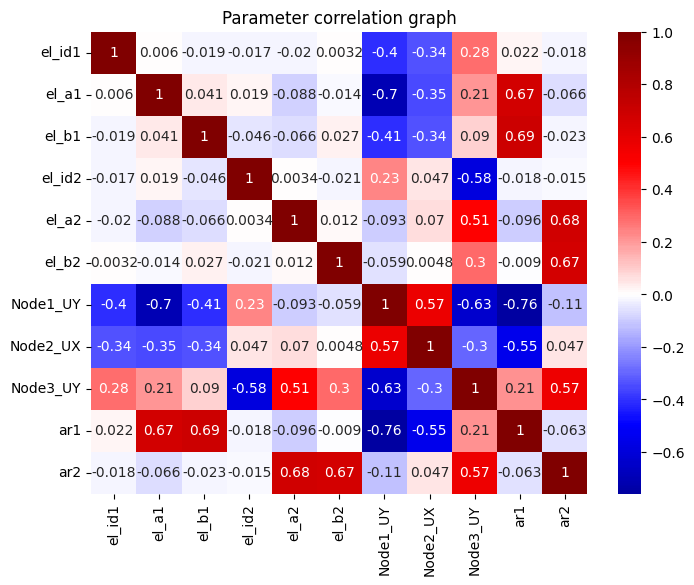

In [3]:
plt.figure(figsize=(8, 6))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

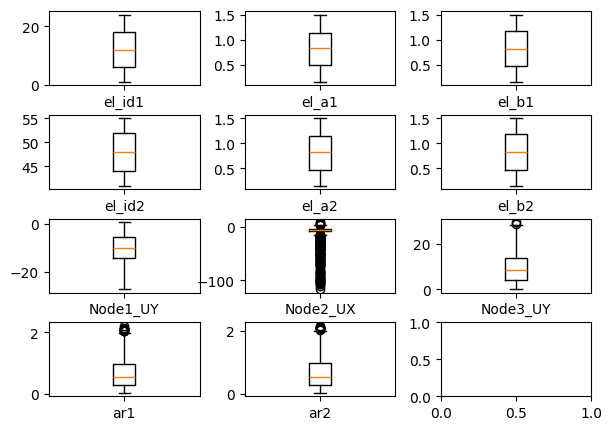

In [4]:
labels = df.columns.to_list()

fig, ax = plt.subplots(4, 3, figsize=(7, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.3) 

for i in range(11):
    ax[i // 3, i % 3].boxplot(df.loc[:,[labels[i]]], tick_labels = [labels[i]])

plt.show()

In [109]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY']].to_numpy()
y = df[['ar1']].to_numpy() 
#y = df[['el_id1','el_id2', 'ar1', 'ar2', 'el_a1', 'el_a2']].to_numpy() 

scaler_X_1 = StandardScaler()
X_scaled = scaler_X_1.fit_transform(X)

scaler_y_1 = StandardScaler()
y_scaled = scaler_y_1.fit_transform(y)

In [110]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=42,
    shuffle=True
)

In [111]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

clf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, criterion = 'squared_error'
                             , min_samples_leaf=2, random_state=42, verbose=0, bootstrap=True, max_samples=500, max_features='sqrt',warm_start=True)
clf.fit(x_train, y_train)

print(f'r2 на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')
print(f'r2 на всей выборке: {clf.score(X_scaled, y_scaled):.3f}')

r2 на обучающей выборке: 0.901, на тествой: 0.823
r2 на всей выборке: 0.890


D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [8]:
import joblib

#joblib.dump(clf, 'model_2_zones_part_1.pkl')
#joblib.dump(scaler_X_1, 'scaler_X_2_zones_part_1.pkl')
#joblib.dump(scaler_y_1, 'scaler_y_2_zones_part_1.pkl')

['scaler_y_2_zones_part_1.pkl']

In [112]:
pred = scaler_y_1.inverse_transform(clf.predict(X_scaled).reshape(-1,1))
X_new = np.hstack((X, pred))

In [113]:
#X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'ar1']].to_numpy()
X = X_new
y = df[['el_id1']].to_numpy() 
#,'el_id2', 'ar2', 'el_a1', 'el_a2'
scaler_X_2 = StandardScaler()
X_scaled = scaler_X_2.fit_transform(X)

scaler_y_2 = StandardScaler()
y_scaled = scaler_y_2.fit_transform(y)

In [114]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=44,
    shuffle=True
)

In [127]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

clf = RandomForestRegressor(n_estimators=400, max_depth=25, min_samples_split=2, criterion = 'squared_error'
                            , min_samples_leaf=1, random_state=42, verbose=0, bootstrap=True
                            , max_samples=450
                            , max_features='sqrt'
                            ,warm_start=True
                           )
clf.fit(x_train, y_train)

print(f'r2 на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')
print(f'r2 на всей выборке: {clf.score(X_scaled, y_scaled):.3f}')

D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2 на обучающей выборке: 0.851, на тествой: 0.538
r2 на всей выборке: 0.802


In [128]:
import joblib

# joblib.dump(clf, 'model_2_zones_part_2.pkl')
# joblib.dump(scaler_X_2, 'scaler_X_2_zones_part_2.pkl')
# joblib.dump(scaler_y_2, 'scaler_y_2_zones_part_2.pkl')

['scaler_y_2_zones_part_2.pkl']

In [129]:
pred = scaler_y_2.inverse_transform(clf.predict(X_scaled).reshape(-1,1))
X_new = np.hstack((X, pred))

In [130]:
#X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'ar1', 'el_id1']].to_numpy()
X = X_new
y = df[['el_a1']].to_numpy() 
#'el_id2', 'ar2', 'el_a1', 'el_a2'
scaler_X_3 = StandardScaler()
X_scaled = scaler_X_3.fit_transform(X)

scaler_y_3 = StandardScaler()
y_scaled = scaler_y_3.fit_transform(y)

In [131]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=45,
    shuffle=True
)

In [134]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

clf = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=2, criterion = 'squared_error'
                            , min_samples_leaf=2, random_state=42, verbose=0, bootstrap=True
                            , max_samples=500
                            , max_features='sqrt'
                            #,warm_start=True
                           )
clf.fit(x_train, y_train)

print(f'r2 на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')
print(f'r2 на всей выборке: {clf.score(X_scaled, y_scaled):.3f}')

D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2 на обучающей выборке: 0.858, на тествой: 0.618
r2 на всей выборке: 0.825


In [135]:
import joblib

#joblib.dump(clf, 'model_2_zones_part_3.pkl')
#joblib.dump(scaler_X_3, 'scaler_X_2_zones_part_3.pkl')
#joblib.dump(scaler_y_3, 'scaler_y_2_zones_part_3.pkl')

['scaler_y_2_zones_part_3.pkl']

In [136]:
pred = scaler_y_3.inverse_transform(clf.predict(X_scaled).reshape(-1,1))
X_new = np.hstack((X, pred))

In [137]:
#X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'ar1', 'el_id1', 'el_a1']].to_numpy()
X = X_new
y = df[['ar2']].to_numpy() 
#'el_id2', 'ar2', 'el_a2'
scaler_X_4 = StandardScaler()
X_scaled = scaler_X_4.fit_transform(X)

scaler_y_4 = StandardScaler()
y_scaled = scaler_y_4.fit_transform(y)

In [138]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=46,
    shuffle=True
)

In [174]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

clf = RandomForestRegressor(n_estimators=1000, max_depth=30, min_samples_split=2, criterion = 'squared_error'
                            , min_samples_leaf=2, random_state=46, verbose=0, bootstrap=True
                            , max_samples=700
                            , max_features='sqrt'
                            ,warm_start=True
                           )

clf.fit(x_train, y_train)

print(f'r2 на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')
print(f'r2 на всей выборке: {clf.score(X_scaled, y_scaled):.3f}')

D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2 на обучающей выборке: 0.828, на тествой: 0.389
r2 на всей выборке: 0.763


In [175]:
# import joblib

# joblib.dump(clf, 'model_2_zones_part_4.pkl')
# joblib.dump(scaler_X_4, 'scaler_X_2_zones_part_4.pkl')
# joblib.dump(scaler_y_4, 'scaler_y_2_zones_part_4.pkl')

['scaler_y_2_zones_part_4.pkl']

In [176]:
pred = scaler_y_4.inverse_transform(clf.predict(X_scaled).reshape(-1,1))
X_new = np.hstack((X, pred))

In [177]:
X = X_new
#X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'ar1', 'el_id1', 'el_a1','ar2']].to_numpy()
y = df[['el_id2']].to_numpy() 
# 'el_a2'
scaler_X_5 = StandardScaler()
X_scaled = scaler_X_5.fit_transform(X)

scaler_y_5 = StandardScaler()
y_scaled = scaler_y_5.fit_transform(y)

In [178]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=53,
    shuffle=True
)

In [220]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers

inputs = tf.keras.Input(shape=(x_train.shape[1],))

x = layers.Dense(4096)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(2048, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(1024, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation='leaky_relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation='leaky_relu')(x)
x = layers.Dense(8, activation='leaky_relu')(x)
x = layers.Dense(4, activation='leaky_relu')(x)

outputs = layers.Dense(1, activation='linear')(x)

model = Model(inputs, outputs)

model.compile( optimizer = keras.optimizers.Adam(learning_rate = 1e-4),
                loss= 'mse',
                metrics = ['mae']
                )

callbacks = [
    EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=75, min_lr=1e-6, verbose=1)
]

In [221]:
model.fit(x_train
          , y_train
          , validation_split=0.15, batch_size=128, epochs=2000
            ,callbacks=callbacks
            , verbose=0, shuffle=True)


Epoch 206: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Restoring model weights from the end of the best epoch: 131.

Epoch 281: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 281: early stopping


In [222]:
from sklearn.metrics import r2_score

y_pred_scaled_train = model.predict(x_train)
y_pred_scaled_test = model.predict(x_test)
y_pred_scaled_all = model.predict(X_scaled)

r2_train= r2_score(y_train, y_pred_scaled_train)
r2_test= r2_score( y_test, y_pred_scaled_test) #, multioutput='raw_values'
r2_all= r2_score(y_scaled, y_pred_scaled_all)

print(f"r2 на обучающей выборке :{np.round(r2_train, 2)}")
print(f"r2 на тестовой выборке :{np.round(r2_test, 2)}")
print(f"r2 на всей выборке :{np.round(r2_all, 2)}")

32/32 [==============================] - 0s 9ms/step
r2 на обучающей выборке :0.78
r2 на тестовой выборке :0.59
r2 на всей выборке :0.75


In [223]:
import joblib

# model.save('model_2_zones_part_5', save_format='tf')
# joblib.dump(scaler_X_5, 'scaler_X_2_zones_part_5.pkl')
# joblib.dump(scaler_y_5, 'scaler_y_2_zones_part_5.pkl')

INFO:tensorflow:Assets written to: model_2_zones_part_5\assets


['scaler_y_2_zones_part_5.pkl']

In [224]:
pred = scaler_y_5.inverse_transform(model.predict(X_scaled))
X_new = np.hstack((X, pred))

32/32 [==============================] - 0s 6ms/step


In [225]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler

#X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'ar1', 'el_id1', 'el_a1','ar2', 'el_id2']].to_numpy()
X = X_new
y = df[['el_a2']].to_numpy() 

scaler_X_6 = StandardScaler()
X_scaled = scaler_X_6.fit_transform(X)

scaler_y_6 = StandardScaler()
y_scaled = scaler_y_6.fit_transform(y)

In [226]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=55,
    shuffle=True
)

In [239]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers

inputs = tf.keras.Input(shape=(x_train.shape[1],))

x = layers.Dense(4096)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(2048, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(1024, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation='leaky_relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation='leaky_relu')(x)
x = layers.Dense(8, activation='leaky_relu')(x)
x = layers.Dense(4, activation='leaky_relu')(x)

outputs = layers.Dense(1, activation='linear')(x)

model = Model(inputs, outputs)

model.compile( optimizer = keras.optimizers.Adam(learning_rate = 1e-4),
                loss= 'mse',
                metrics = ['mae']
                )

callbacks = [
    EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=75, min_lr=1e-6, verbose=1)
]

In [240]:
model.fit(x_train
          , y_train
          , validation_split=0.2, batch_size=128, epochs=2000
            ,callbacks=callbacks
            , verbose=0, shuffle = True)


Epoch 201: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Restoring model weights from the end of the best epoch: 126.

Epoch 276: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 276: early stopping


In [241]:
from sklearn.metrics import r2_score

y_pred_scaled_train = model.predict(x_train)
y_pred_scaled_test = model.predict(x_test)
y_pred_scaled_all = model.predict(X_scaled)

r2_train= r2_score(y_train, y_pred_scaled_train)
r2_test= r2_score( y_test, y_pred_scaled_test) #, multioutput='raw_values'
r2_all= r2_score(y_scaled, y_pred_scaled_all)

print(f"r2 на обучающей выборке :{np.round(r2_train, 2)}")
print(f"r2 на тестовой выборке :{np.round(r2_test, 2)}")
print(f"r2 на всей выборке :{np.round(r2_all, 2)}")

32/32 [==============================] - 0s 9ms/step
r2 на обучающей выборке :0.75
r2 на тестовой выборке :0.42
r2 на всей выборке :0.7


In [242]:
import joblib

#model.save('model_2_zones_part_6', save_format='tf')
#joblib.dump(scaler_X_6, 'scaler_X_2_zones_part_6.pkl')
#joblib.dump(scaler_y_6, 'scaler_y_2_zones_part_6.pkl')

INFO:tensorflow:Assets written to: model_2_zones_part_6\assets


['scaler_y_2_zones_part_6.pkl']

In [ ]:
#---------------test-----------------

In [3]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler
import joblib
import tensorflow as tf

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY']].to_numpy()
y = df[['ar1', 'el_id1', 'el_a1', 'ar2', 'el_id2', 'el_a2']].to_numpy()

scaler_X_1 = joblib.load('scaler_X_2_zones_part_1.pkl')
scaler_y_1 = joblib.load('scaler_y_2_zones_part_1.pkl')

scaler_X_2 = joblib.load('scaler_X_2_zones_part_2.pkl')
scaler_y_2 = joblib.load('scaler_y_2_zones_part_2.pkl')

scaler_X_3 = joblib.load('scaler_X_2_zones_part_3.pkl')
scaler_y_3 = joblib.load('scaler_y_2_zones_part_3.pkl')

scaler_X_4 = joblib.load('scaler_X_2_zones_part_4.pkl')
scaler_y_4 = joblib.load('scaler_y_2_zones_part_4.pkl')

scaler_X_5 = joblib.load('scaler_X_2_zones_part_5.pkl')
scaler_y_5 = joblib.load('scaler_y_2_zones_part_5.pkl')

scaler_X_6 = joblib.load('scaler_X_2_zones_part_6.pkl')
scaler_y_6 = joblib.load('scaler_y_2_zones_part_6.pkl')

reg_1 = joblib.load('model_2_zones_part_1.pkl')
reg_2 = joblib.load('model_2_zones_part_2.pkl')
reg_3 = joblib.load('model_2_zones_part_3.pkl')
reg_4 = joblib.load('model_2_zones_part_4.pkl')
model_5 = tf.keras.models.load_model('model_2_zones_part_5')
model_6 = tf.keras.models.load_model('model_2_zones_part_6')


In [4]:
X_scaled = scaler_X_1.transform(X)

pred = scaler_y_1.inverse_transform(reg_1.predict(X_scaled).reshape(-1,1))

X_new = np.hstack((X, pred))

In [5]:
X_scaled = scaler_X_2.transform(X_new)

pred = scaler_y_2.inverse_transform(reg_2.predict(X_scaled).reshape(-1,1))

X_new = np.hstack((X_new, pred))

In [6]:
X_scaled = scaler_X_3.transform(X_new)

pred = scaler_y_3.inverse_transform(reg_3.predict(X_scaled).reshape(-1,1))

X_new = np.hstack((X_new, pred))

In [7]:
X_scaled = scaler_X_4.transform(X_new)

pred = scaler_y_4.inverse_transform(reg_4.predict(X_scaled).reshape(-1,1))

X_new = np.hstack((X_new, pred))

In [8]:
X_scaled = scaler_X_5.transform(X_new)

pred_scal = model_5.predict(X_scaled)
pred = scaler_y_5.inverse_transform(pred_scal)

X_new = np.hstack((X_new, pred))

32/32 [==============================] - 1s 14ms/step


In [9]:
X_scaled = scaler_X_6.transform(X_new)

pred_scal = model_6.predict(X_scaled)
pred = scaler_y_6.inverse_transform(pred_scal)

X_new = np.hstack((X_new, pred))

32/32 [==============================] - 1s 14ms/step


In [10]:
from sklearn.metrics import r2_score

y_pred = X_new[:,3:]

r2 = r2_score(y, y_pred, multioutput='raw_values')
print(f"r2 итоговой модели (6 выходных параметров): {np.round(r2, 2)}")

r2 итоговой модели (6 выходных параметров): [0.89 0.8  0.83 0.76 0.75 0.7 ]
